# 01 — Explore Aya Global Teacher Model

**Goal**: Load CohereLabs/tiny-aya-global (3.35B params, 70+ languages), profile tokenizer efficiency across all languages, and measure inference quality.

This notebook demonstrates the `aya-distill` package for multilingual model evaluation.

| Stat | Value |
|------|-------|
| Model | `CohereLabs/tiny-aya-global` |
| Parameters | 3.35B |
| Languages | 70+ |
| Architecture | 4-layer transformer (3 sliding window + 1 global attention) |
| Context | 8K input / 8K output |

In [1]:
import sys
from pathlib import Path

# Ensure package is importable
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import torch
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

from aya_distill.languages import (
    LANGUAGES, LANGUAGE_NAMES, LANGUAGE_FAMILIES,
    RESOURCE_GROUPS, REGION_GROUPS, SCRIPT_GROUPS,
    DISTILLATION_LANGUAGES,
)

print(f"aya-distill: {len(LANGUAGES)} languages, {len(LANGUAGE_FAMILIES)} families")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

aya-distill: 67 languages, 13 families
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1. Language Registry

The `aya_distill.languages` module is the single source of truth for all 67 target languages, organized by family, script, typology, resourcedness, and region.

In [2]:
# Build a comprehensive language table
rows = []
for code in sorted(LANGUAGES.keys()):
    lang = LANGUAGES[code]
    rows.append({
        "Code": code,
        "Language": lang.name,
        "Family": lang.family,
        "Script": lang.script,
        "Typology": lang.typology,
        "Resources": lang.resourcedness,
        "Region": lang.region,
    })
df_langs = pd.DataFrame(rows)
print(f"Total: {len(df_langs)} languages across {df_langs['Family'].nunique()} families, "
      f"{df_langs['Script'].nunique()} scripts, {df_langs['Region'].nunique()} regions")
print(f"\nBy resourcedness: {df_langs['Resources'].value_counts().to_dict()}")
print(f"By region: {df_langs['Region'].value_counts().to_dict()}")
df_langs.head(20)

Total: 67 languages across 13 families, 19 scripts, 6 regions

By resourcedness: {'medium': 29, 'low': 25, 'high': 13}
By region: {'Europe': 32, 'Africa': 10, 'Southeast Asia': 9, 'South Asia': 9, 'Middle East': 4, 'East Asia': 3}


,Code,Language,Family,Script,Typology,Resources,Region
0,am,Amharic,Afroasiatic,Ethiopic,Fusional,low,Africa
1,ar,Arabic,Afroasiatic,Arabic,Fusional,high,Middle East
2,bg,Bulgarian,Indo-European,Cyrillic,Fusional,medium,Europe
3,bn,Bengali,Indo-European,Bengali,Fusional,medium,South Asia
4,ca,Catalan,Indo-European,Latin,Fusional,medium,Europe
5,cs,Czech,Indo-European,Latin,Fusional,medium,Europe
6,cy,Welsh,Indo-European,Latin,Fusional,low,Europe
7,da,Danish,Indo-European,Latin,Fusional,medium,Europe
8,de,German,Indo-European,Latin,Fusional,high,Europe
9,el,Greek,Indo-European,Greek,Fusional,medium,Europe


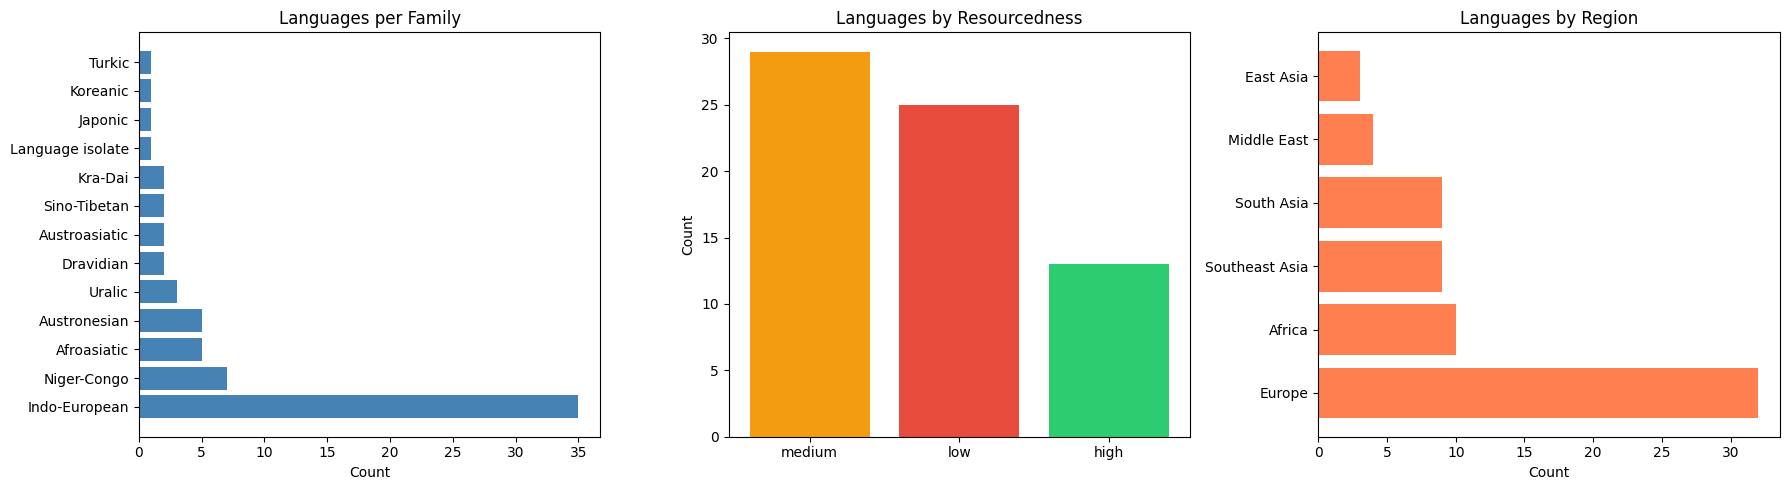

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By family
family_counts = df_langs["Family"].value_counts()
axes[0].barh(family_counts.index, family_counts.values, color="steelblue")
axes[0].set_title("Languages per Family")
axes[0].set_xlabel("Count")

# By resourcedness
res_counts = df_langs["Resources"].value_counts()
colors = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
axes[1].bar(res_counts.index, res_counts.values, color=[colors[r] for r in res_counts.index])
axes[1].set_title("Languages by Resourcedness")
axes[1].set_ylabel("Count")

# By region
reg_counts = df_langs["Region"].value_counts()
axes[2].barh(reg_counts.index, reg_counts.values, color="coral")
axes[2].set_title("Languages by Region")
axes[2].set_xlabel("Count")

plt.tight_layout()
Path("../results").mkdir(exist_ok=True)
plt.savefig("../results/language_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Tokenizer Analysis

Load the tokenizer (fast, no model download needed) and analyze encoding efficiency across all 67 languages. Languages with higher tokens-per-word ratios are encoded less efficiently -- a key source of inequity.

In [4]:
from transformers import AutoTokenizer

MODEL_NAME = "CohereLabs/tiny-aya-global"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print(f"Vocab size: {tokenizer.vocab_size:,}")

# Import test prompts from the package
from aya_distill.testing.fixtures import MULTILINGUAL_PROMPTS
prompts = MULTILINGUAL_PROMPTS["general_knowledge"]

# Analyze tokenizer efficiency for all languages with prompts
rows = []
for code in sorted(prompts.keys()):
    text = prompts[code]
    tokens = tokenizer.encode(text)
    words = text.split()
    lang = LANGUAGES.get(code)
    if lang is None:
        continue
    rows.append({
        "code": code,
        "language": lang.name,
        "family": lang.family,
        "script": lang.script,
        "resources": lang.resourcedness,
        "region": lang.region,
        "chars": len(text),
        "words": len(words),
        "tokens": len(tokens),
        "tok_per_word": round(len(tokens) / max(len(words), 1), 2),
        "tok_per_char": round(len(tokens) / max(len(text), 1), 4),
    })

df_tok = pd.DataFrame(rows).sort_values("tok_per_word", ascending=False)
print(f"Analyzed {len(df_tok)} languages")
print(f"\nMedian tok/word: {df_tok['tok_per_word'].median():.2f}")
print(f"Max: {df_tok.iloc[0]['language']} ({df_tok.iloc[0]['tok_per_word']:.2f})")
print(f"Min: {df_tok.iloc[-1]['language']} ({df_tok.iloc[-1]['tok_per_word']:.2f})")
print(f"Max/Min ratio: {df_tok['tok_per_word'].max() / df_tok['tok_per_word'].min():.1f}x")
df_tok[["code", "language", "family", "script", "words", "tokens", "tok_per_word"]].head(20)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

Vocab size: 261,000
Analyzed 67 languages

Median tok/word: 2.60
Max: Khmer (50.00)
Min: English (1.25)
Max/Min ratio: 40.0x


,code,language,family,script,words,tokens,tok_per_word
30,km,Khmer,Austroasiatic,Khmer,1,50,50.00
56,th,Thai,Kra-Dai,Thai,1,35,35.00
32,lo,Lao,Kra-Dai,Lao,1,32,32.00
28,ja,Japanese,Japonic,CJK+Kana,1,12,12.00
39,my,Burmese,Sino-Tibetan,Myanmar,4,47,11.75
65,zh,Chinese,Sino-Tibetan,CJK,1,9,9.00
19,gu,Gujarati,Indo-European,Gujarati,5,41,8.20
54,ta,Tamil,Dravidian,Tamil,6,47,7.83
40,ne,Nepali,Indo-European,Devanagari,6,45,7.50
55,te,Telugu,Dravidian,Telugu,5,37,7.40


/tmp/ipykernel_1170974/3261742686.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(family_data, labels=family_labels, vert=False)


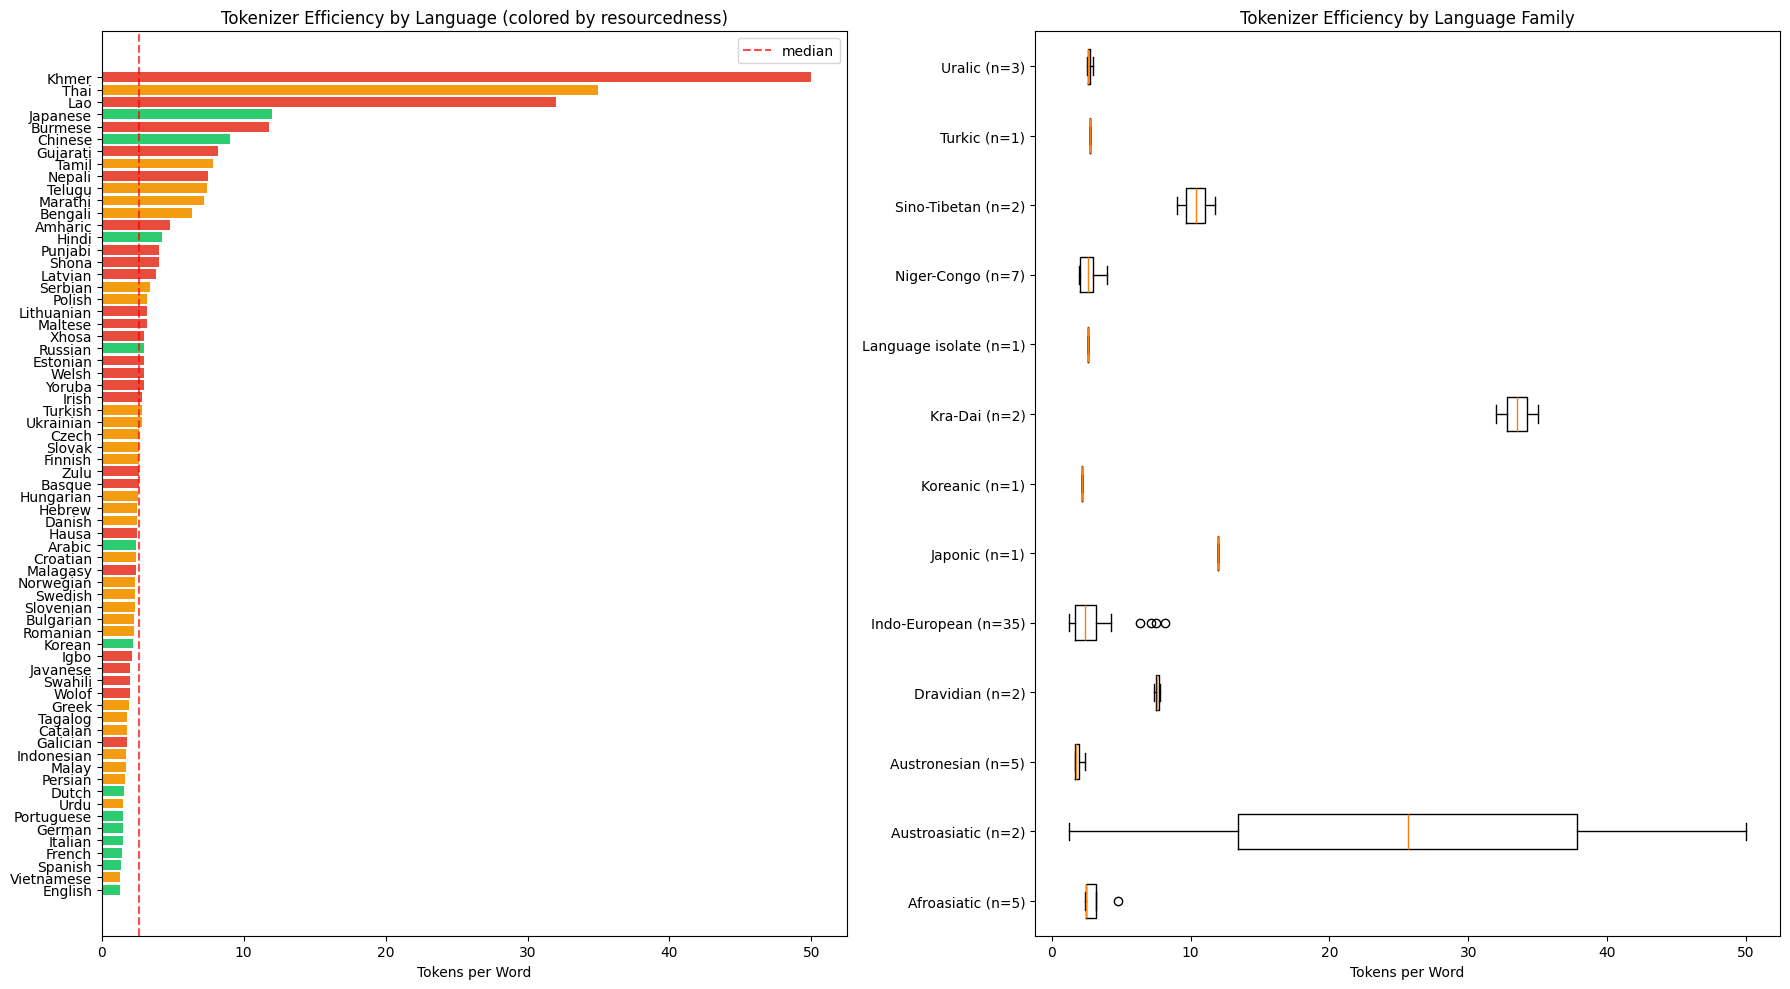

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Sort by tok_per_word for the bar chart
df_sorted = df_tok.sort_values("tok_per_word")

# Color by resourcedness
color_map = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
colors = [color_map[r] for r in df_sorted["resources"]]

ax = axes[0]
ax.barh(df_sorted["language"], df_sorted["tok_per_word"], color=colors)
ax.axvline(x=df_tok["tok_per_word"].median(), color="red", linestyle="--", alpha=0.7, label="median")
ax.set_xlabel("Tokens per Word")
ax.set_title("Tokenizer Efficiency by Language (colored by resourcedness)")
ax.legend()

# Tokens per word by family (boxplot)
ax = axes[1]
family_data = []
family_labels = []
for family in sorted(df_tok["family"].unique()):
    vals = df_tok[df_tok["family"] == family]["tok_per_word"].values
    if len(vals) > 0:
        family_data.append(vals)
        family_labels.append(f"{family} (n={len(vals)})")
ax.boxplot(family_data, labels=family_labels, vert=False)
ax.set_xlabel("Tokens per Word")
ax.set_title("Tokenizer Efficiency by Language Family")

plt.tight_layout()
plt.savefig("../results/tokenizer_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Load Model

tiny-aya-global is 3.35B parameters -- loads in ~1-2 minutes on GPU, ~3-5 on CPU. No quantization needed for 4GB VRAM.

In [ ]:
from transformers import AutoModelForCausalLM

mem_before = psutil.Process().memory_info().rss / 1024**3
gpu_before = torch.cuda.memory_allocated() / 1024**3 if torch.cuda.is_available() else 0

t0 = time.perf_counter()
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
load_time = time.perf_counter() - t0

mem_after = psutil.Process().memory_info().rss / 1024**3
gpu_after = torch.cuda.memory_allocated() / 1024**3 if torch.cuda.is_available() else 0

print(f"Load time: {load_time:.1f}s")
print(f"RAM: {mem_before:.2f} -> {mem_after:.2f} GB (+{mem_after - mem_before:.2f})")
print(f"GPU: {gpu_before:.2f} -> {gpu_after:.2f} GB (+{gpu_after - gpu_before:.2f})")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Dtype: {next(model.parameters()).dtype}")

## 4. Multilingual Inference

Generate responses across a diverse subset of languages using the package's testing framework.

In [ ]:
from aya_distill.testing import MultilingualTestSuite

# Pick a diverse subset (one per region + resource level)
test_langs = ["en", "es", "de", "ru", "ar", "hi", "zh", "ja", "ko", "th", "vi", "sw", "yo", "tr", "id"]

def generate(prompt: str) -> str:
    messages = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    with torch.inference_mode():
        out = model.generate(input_ids, max_new_tokens=128, do_sample=False)
    return tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)

suite = MultilingualTestSuite(model_fn=generate, languages=test_langs)
result = suite.run()
print(result.summary())

In [ ]:
from aya_distill.testing import ToolCallingTest
from aya_distill.testing.fixtures import TOOL_SCENARIOS

tool_test = ToolCallingTest(model_fn=generate)
tool_langs = ["en", "es", "fr", "de", "ar", "hi", "zh", "ja", "ko", "sw"]
scenarios = {k: v for k, v in TOOL_SCENARIOS.items() if k in tool_langs}
tool_results = tool_test.run_multilingual(scenarios=scenarios)

print(f"\nTool Calling Results ({len(tool_results)} languages)")
print("=" * 60)
for lang, r in tool_results.items():
    print(f"  {lang} ({r.language:>10}): json={r.json_valid} fn={r.function_correct} args={r.args_correct} score={r.score:.2f}")

## 5. Cohere Evaluation Checklist

Validate our evaluation against the Cohere multilingual LLM evaluation checklist (25 items, 7 categories).

In [ ]:
from aya_distill.eval.checklist import validate_results

# Build a results dict from our evaluation
eval_results = {
    "model": MODEL_NAME,
    "model_version": "main",
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%SZ"),
    "seed": 42,
    "hardware": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "per_language": {},
    "language_families": {},
    "prompt_templates": {"type": "native", "versioned": True},
    "metrics": {"primary": "accuracy", "additional": ["tokens_per_second", "coherence"]},
    "decoding": {"temperature": 0.0, "do_sample": False, "max_new_tokens": 128},
}

# Add per-language results
for lang, lr in result.language_results.items():
    eval_results["per_language"][lang] = {
        "accuracy": lr.coherence_score,
        "n_samples": 1,
        "confidence_interval": {"lower": 0.0, "upper": 1.0, "n_bootstrap": 0},
    }

# Add family aggregation
for family, codes in LANGUAGE_FAMILIES.items():
    tested = [c for c in codes if c in result.language_results]
    if tested:
        scores = [result.language_results[c].coherence_score for c in tested]
        eval_results["language_families"][family] = {
            "languages": tested,
            "mean_accuracy": round(np.mean(scores), 3),
        }

report = validate_results(eval_results)
report.print_report()

In [ ]:
# Save all results
profile = {
    "model": MODEL_NAME,
    "load_time_s": round(load_time, 1),
    "params": sum(p.numel() for p in model.parameters()),
    "n_languages": len(LANGUAGES),
    "tokenizer_vocab_size": tokenizer.vocab_size,
    "tokenizer_analysis": df_tok.to_dict(orient="records"),
    "multilingual_test": result.to_dict() if hasattr(result, "to_dict") else str(result),
    "checklist_compliant": report.compliant,
    "checklist_score": f"{report.n_passed}/{len(report.results)}",
}
Path("../results").mkdir(exist_ok=True)
with open("../results/01_teacher_profile.json", "w") as f:
    json.dump(profile, f, indent=2, default=str)
print(f"Saved to results/01_teacher_profile.json")